C:\Users\veron\AppData\Local\Temp\ipykernel_10100\1797537715.py:62: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Rows: 24497
Medication prevalence: 0.19573825366371392
Med group: 4795
Ctrl group: 19702


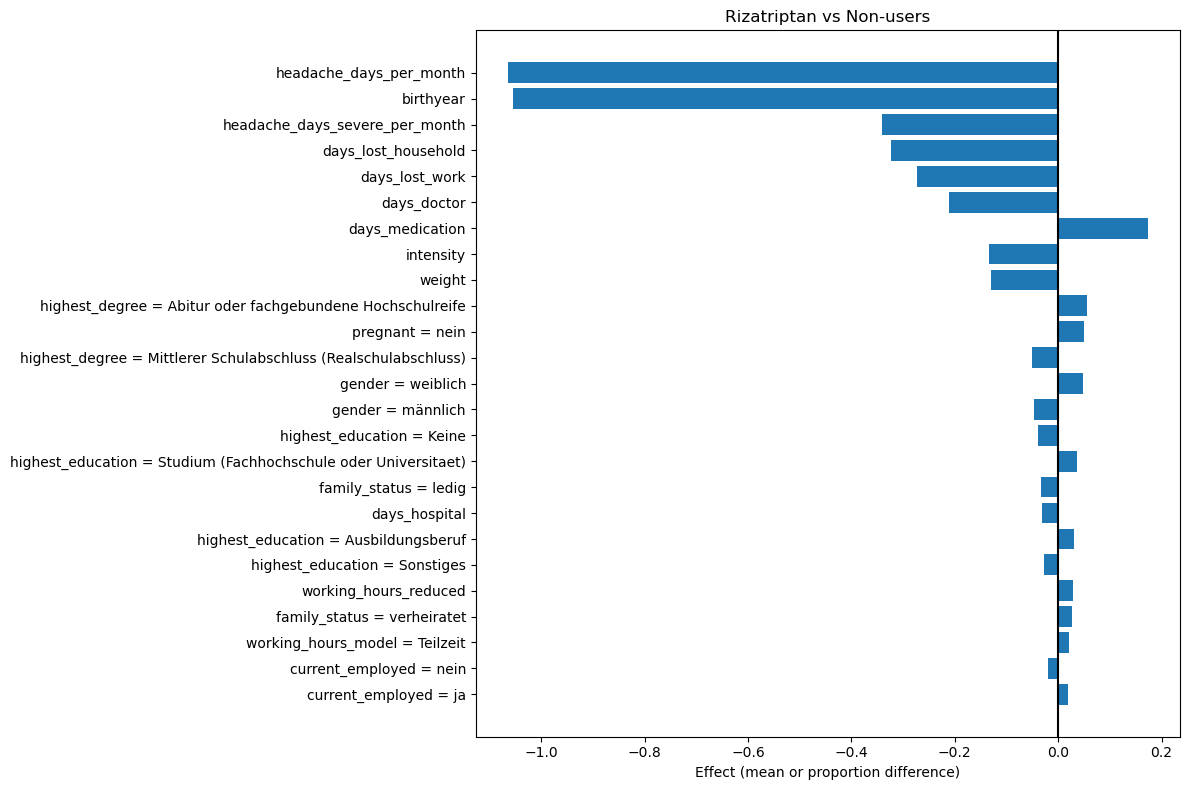

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

MEDICATION_QUERY = "Rizatriptan"

factor_prefixes = [
    "gender","birthyear","weight","pregnant",
    "highest_degree","highest_education","family_status",
    "current_employed","working_hours_model","shiftwork",
    "working_hours_reduced","promotion_waived","children",
    "headache_days_per_month","headache_days_severe_per_month",
    "days_medication","intensity","days_lost_work",
    "days_lost_household","days_doctor","days_ER","days_hospital"
]

# =========================================================
# SAFE K-COLLAPSE (UNCHANGED)
# =========================================================

def collapse_k_columns(df, prefixes):

    out = {}

    for p in prefixes:

        cols = [c for c in df.columns if c.startswith(p)]
        if not cols:
            continue

        block = df[cols]

        sample = block.stack().dropna()
        numeric_ratio = pd.to_numeric(sample, errors="coerce").notna().mean()

        if numeric_ratio > 0.7:
            num_block = block.apply(pd.to_numeric, errors="coerce")
            out[p] = num_block.mean(axis=1)

        else:
            out[p] = block.bfill(axis=1).iloc[:, 0].astype(str)

    return pd.DataFrame(out)

# =========================================================
# LOAD DATA (ONLY MEDICATION DETECTION CHANGED)
# =========================================================

frames = []

for file in csv_files:

    df = pd.read_csv(file, sep=";")

    med_cols = [c for c in df.columns if c.startswith("acute_name_a")]
    if not med_cols:
        continue

    med_text = df[med_cols].astype(str).agg(" ".join, axis=1).str.lower()

    # =====================================================
    # FIXED MEDICATION DETECTION (ROBUST SUBSTRING MATCH)
    # =====================================================

    med_query = MEDICATION_QUERY.lower()

    df["has_med"] = med_text.str.contains(med_query, na=False)

    # keep your original logic unchanged
    df["any_med"] = med_text.str.contains(r"\w", na=False)

    collapsed = collapse_k_columns(df, factor_prefixes)

    collapsed["has_med"] = df["has_med"].values
    collapsed["any_med"] = df["any_med"].values

    frames.append(collapsed)

data = pd.concat(frames, ignore_index=True)

print("Rows:", len(data))
print("Medication prevalence:", data["has_med"].mean())

# =========================================================
# GROUPS (UNCHANGED)
# =========================================================

med = data[data["has_med"]]
ctrl = data[~data["has_med"] & data["any_med"]]

if len(ctrl) < 10:
    ctrl = data[~data["has_med"]]

print("Med group:", len(med))
print("Ctrl group:", len(ctrl))

# =========================================================
# ANALYSIS (UNCHANGED)
# =========================================================

results = []

for col in data.columns:

    if col in ["has_med", "any_med"]:
        continue

    m = med[col]
    c = ctrl[col]

    m_num = pd.to_numeric(m, errors="coerce")
    c_num = pd.to_numeric(c, errors="coerce")

    if m_num.notna().mean() > 0.7:

        results.append({
            "factor": col,
            "effect": m_num.mean() - c_num.mean(),
            "type": "numeric"
        })
        continue

    if m_num.dropna().isin([0, 1]).mean() > 0.95:

        results.append({
            "factor": col,
            "effect": m_num.mean() - c_num.mean(),
            "type": "binary"
        })
        continue

    cats = sorted(set(m.dropna().astype(str)) | set(c.dropna().astype(str)))

    for cat in cats:

        if cat in ["nan", "None", ""]:
            continue

        results.append({
            "factor": f"{col} = {cat}",
            "effect": (m.astype(str) == cat).mean() - (c.astype(str) == cat).mean(),
            "type": "categorical"
        })

# =========================================================
# PLOT (UNCHANGED)
# =========================================================

res = pd.DataFrame(results).dropna()

res["abs"] = res["effect"].abs()
res = res.sort_values("abs").tail(25)

plt.figure(figsize=(12, 8))

plt.barh(res["factor"], res["effect"])
plt.axvline(0, color="black")

plt.title("Rizatriptan vs Non-users")
plt.xlabel("Effect (mean or proportion difference)")

plt.tight_layout()
plt.show()